# Spectral analysis of Photron SA-Z high speed images

This program loads Sanjiv's cavitation nozzle images from Photron SA-Z, and calculates average spectra and spectral heat maps.

I have designed the code to handle very large arrays which may exceed the memory limit of a typical PC by loading the images in chunks, limiting bit depth to int16 and float32, and processing the arrays using for-loops by row of pixels rather than using numpy matrix functions on the whole array.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 26/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


## Stage 1. Load images, crop, and remove background.


In [1]:
# core functions for image handling and plotting
from pySciCam.pySciCam import ImageSequence # https://github.com/djorlando24/pySciCam

import numpy as np
import os
from scipy.signal import welch
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

In [2]:
# Images to load

#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'


In [3]:
# Load background
B=ImageSequence(src_images,width=1024,height=1024, rawtype='photron_mraw_mono_16bit',\
               frames=(0,800))

Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw
PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 0 to 800
Read 1600.0 MiB in 17.9 sec
	Data in memory:	 (800, 1024, 1024)
	Intensity range:	 0 to 31264 	 uint16
	Array size:	1600.0 MB


In [4]:
# Find number of frames to analyze
nframes = os.path.getsize(src_images)//(B.width*B.height*2)
print("MRAW file has %i frames" % nframes)

MRAW file has 43682 frames


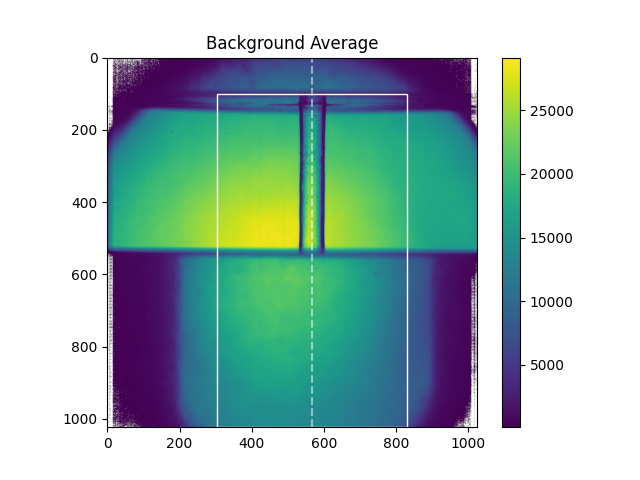

In [5]:
# Background time-averaging
avgBkgnd=np.nanmean(B.arr,axis=0)

# Make a temporary mask to hide dark areas
avgBkgndMasked=avgBkgnd[...]
avgBkgndMasked[avgBkgndMasked<100]=np.nan

# Show background and check cropping
fig=plt.figure()
crop=(100,1024,305,830)
ph=plt.imshow(avgBkgndMasked)

plt.colorbar();
cropBox=mpl.patches.Rectangle((crop[2],crop[0]),crop[3]-crop[2],crop[1]-crop[0],fc='None',ec='w')
plt.axvline((crop[2]+crop[3])//2,c='w',ls='--',alpha=.5)
fig.gca().add_patch(cropBox);
plt.title("Background Average");

# Apply to avgBkgnd
avgBkgnd=avgBkgnd[crop[0]:crop[1]+1,crop[2]:crop[3]+1]


In [7]:
# Remove original background images to save on memory
del B

In [9]:
# Function to load some images and peform backgorund correction 
def load_chunk_of_images_from_mraw(filename,offset=0,width=1024,height=1024,\
                                   rawtype='photron_mraw_mono_16bit',\
                                   chunk_size=512):
    
    # Load chunk of frames to restrain RAM requirement
    Iset=ImageSequence(filename,width=width,height=height,rawtype=rawtype,\
               frames=(offset,offset+chunk_size))

    # Apply crop same as to bkgnd, from previous 
    Iset.arr = Iset.arr[:,crop[0]:crop[1]+1,crop[2]:crop[3]+1]
    
    # Assign memory to hold new images. Recommend signed 16bit int for subtraction, float32 for division.
    bkRmvSet = np.zeros((Iset.arr.shape[0],Iset.arr.shape[1],Iset.arr.shape[2]),dtype=np.int16) # use float32 for division
    sumIntensSet = np.zeros((Iset.arr.shape[0],))
    sumIntensSet2= np.zeros((Iset.arr.shape[0],))
    
    # Background removal of chunk
    for j in range(Iset.N):
        frame = Iset.arr[j,...].astype(np.int16)

        # division method
        #frame[frame<100]=100 # floor on intensity
        #bkRmvSet[j,...] = avgBkgnd / frame

        # subtraction method
        bkRmvSet[j,...] = frame-avgBkgnd

        # save stats
        sumIntensSet[j]=np.nansum(bkRmvSet[j,...])//(Iset.arr.shape[1]*Iset.arr.shape[2])
        sumIntensSet2[j]=np.nansum(bkRmvSet[j,...]**2)//(Iset.arr.shape[1]*Iset.arr.shape[2])
        
    # clear ImageSequence instance
    del Iset
    
    return bkRmvSet, sumIntensSet, sumIntensSet2

In [10]:
# Run loading function in parallel
chunk_size=1024
start_frame=18500 #B.N

# Write temp files to external SSD to keep internal disk free for shm when fft is large
os.environ['JOBLIB_TEMP_FOLDER'] = '/Volumes/DUKE SSD ext4/tmp'

allOutput=Parallel(n_jobs=4, backend='threading', verbose=25)\
    (delayed(load_chunk_of_images_from_mraw)(src_images,i,chunk_size=chunk_size)\
     for i in range(start_frame,nframes,chunk_size)) 

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mrawReading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw

PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 19524 to 20548
PFV 16-bit MRAW
PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 20548 to 21572
PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 18500 to 19524
File contains 43682 frames (1024 x 1024)Read 2048.0

[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done   2 tasks      | elapsed:  1.6min


Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw
PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 22596 to 23620
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw
PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 23620 to 24644


[Parallel(n_jobs=4)]: Done   3 tasks      | elapsed:  1.6min


...

[Parallel(n_jobs=4)]: Done  20 out of  25 | elapsed:  8.8min remaining:  2.2min


	Intensity range:	 0 to 31264 	 uint16
	Array size:	2048.0 MB
Read 2048.0 MiB in 50.3 secRead 2048.0 MiB in 71.6 sec
	Data in memory:	 (1024, 1024, 1024)
Read 2048.0 MiB in 25.1 sec
	Data in memory:	 (1024, 1024, 1024)

	Data in memory:	 (1024, 1024, 1024)
	Intensity range:	 0 to 31408 	 uint16
	Array size:	2048.0 MB
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw
PFV 16-bit MRAW
File contains 43682 frames (1024 x 1024)
Reading frames 43076 to 44100


[Parallel(n_jobs=4)]: Done  22 out of  25 | elapsed: 10.0min remaining:  1.4min


	Intensity range:	 0 to 31328 	 uint16
	Array size:	2048.0 MB
	Intensity range:	 0 to 31328 	 uint16
	Array size:	2048.0 MB
Read 1212.0 MiB in 26.1 sec
	Data in memory:	 (1024, 1024, 1024)
	Intensity range:	 0 to 31184 	 uint16
	Array size:	2048.0 MB


[Parallel(n_jobs=4)]: Done  25 out of  25 | elapsed: 10.5min finished


In [11]:
# Transfer result into a single NumPy array

sumIntens  = np.hstack([ allOutput[n][1] for n in range(len(allOutput)) ], dtype=np.float32)
sumIntens2 = np.hstack([ allOutput[n][2] for n in range(len(allOutput)) ], dtype=np.float32)

bkRmv=np.zeros((len(sumIntens), avgBkgnd.shape[0], avgBkgnd.shape[1]),dtype=np.int16) # float32 for division
chunk_size=allOutput[0][0].shape[0]
for i in range(start_frame,nframes,chunk_size):
    print(i,'-',i+chunk_size)
    chunk_size=allOutput[0][0].shape[0]
    bkRmv[i-start_frame:i-start_frame+allOutput[0][0].shape[0],...]=allOutput[0][0][...]
    allOutput.pop(0)

18500 - 19524
19524 - 20548
20548 - 21572
21572 - 22596
22596 - 23620
23620 - 24644
24644 - 25668
25668 - 26692
26692 - 27716
27716 - 28740
28740 - 29764
29764 - 30788
30788 - 31812
31812 - 32836
32836 - 33860
33860 - 34884
34884 - 35908
35908 - 36932
36932 - 37956
37956 - 38980
38980 - 40004
40004 - 41028
41028 - 42052
42052 - 43076
43076 - 44100


In [12]:
# Remove unneeded variables
del allOutput

In [ ]:
fig=plt.figure()
p1,=plt.plot(np.sqrt(sumIntens2-sumIntens**2)/float(len(sumIntens)+1),label='rms',c='orange',lw=1,alpha=.5);
p2,=plt.plot(sumIntens/float(len(sumIntens)),label='mean',lw=1,alpha=.5);
plt.legend([p1,p2],['rms','mean']);
#plt.ylim([0,(np.nanmean(sumIntens)+3*np.nanstd(sumIntens))/float(len(sumIntens))])
plt.grid(alpha=.2);
plt.xlabel('time [frame]');
plt.ylabel('intensity');

fig=plt.figure()
ph=plt.imshow(-bkRmv[5000,...],cmap='gnuplot',vmin=0);
plt.colorbar(ph);

In [14]:
# Save processed images
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_bkRmv.npz'
np.savez(npy_path, sumIntens=sumIntens, sumIntens2=sumIntens2, bkRmv=bkRmv)
print("Wrote %.0f MB" % (os.path.getsize(npy_path)//1024//1024))

Wrote 23731 MB


In [15]:
# Save movie
import imageio
#bkRmv[bkRmv>4294967295]=4294967294 # for floats
imageio.mimsave(output_prefix+'_video.mp4', bkRmv.astype(np.uint16))#, fps=30)
print("Wrote %.0f MB" % (os.path.getsize(output_prefix+'_video.mp4')//1024//1024))

error: 'I' format requires 0 <= number <= 4294967295

---
## Stage 2. Spectral analysis



In [1]:
# reload modules if starting script here.
import numpy as np
import os, gc
from scipy.signal import welch
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'

# Load data back
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_bkRmv.npz'
with np.load(npy_path) as file:
    bkRmv = file['bkRmv']

print("Read %s array from %s" % (bkRmv.shape, os.path.basename(npy_path)))

# Roll axis so time is last
bkRmv = np.rollaxis(bkRmv,2)
bkRmv = np.rollaxis(bkRmv,2)
print(bkRmv.shape)

gc.collect();

Read (25600, 924, 526) array from nz_0__5_3_co2_00_Re_1__5E4_K_1__12_bkRmv.npz
(924, 526, 25600)


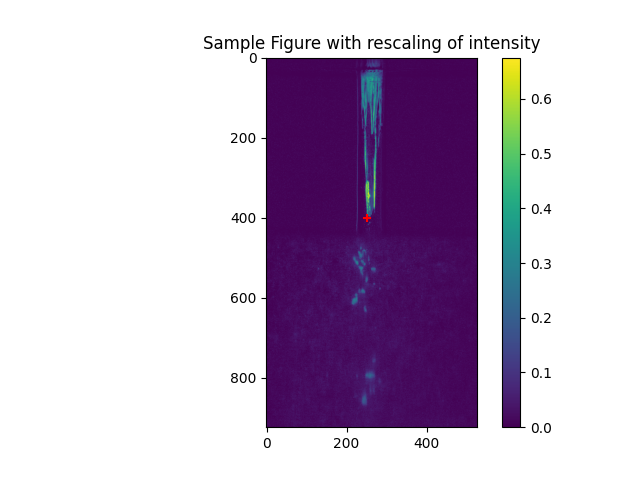

In [8]:
def rescaleImage(I): 
    # clip intensity, set to extinction and rescale to bit depth of original images.
    return -(I*(I<0))/32768.

sample_point = (250,400)

fig=plt.figure()
ph=plt.imshow(rescaleImage(bkRmv[...,5000]))
plt.colorbar(ph);
plt.title("Sample Figure with rescaling of intensity");
plt.scatter(sample_point[0],sample_point[1],c='r',marker='+');

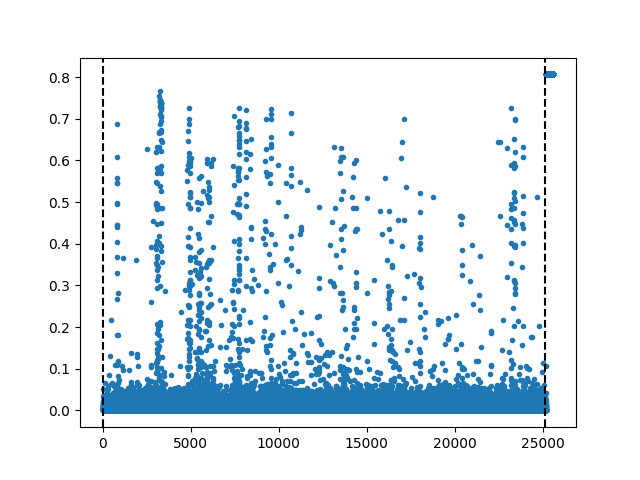

In [11]:
# Check timeseries for any non-stationary behaviour.
# Just look at one pixel inside the nozzle.
# Set t0 to start the timeseries after that behaviour passes.

t0=0
t1=bkRmv.shape[2]-500

fig=plt.figure()
plt.scatter(np.arange(bkRmv.shape[2]),rescaleImage(bkRmv[sample_point[1],sample_point[0],:]),marker='.');
plt.axvline(t0,c='k',ls='--');
plt.axvline(t1,c='k',ls='--');
#plt.gca().set_yscale('log')

In [12]:
# Functions for the Welch Method

nperseg=8192 # output is half this
fs=20000. # fps, obtained from cihx metadata

# Computation of per-pixel spectra
def welch_fun(xx):
    return welch(xx, fs, nperseg=nperseg,\
                 detrend='linear', return_onesided=True,\
                 scaling='density', noverlap=int(nperseg * (3/4)))
    
def welch_vector(x):
    welch_output = np.zeros((x.shape[0], int(nperseg/2 + 1)),dtype=np.float32)
    for j in range(x.shape[0]):
        f, Pxx = welch_fun(rescaleImage(x[j,t0:t1]))
        welch_output[j,:] = Pxx
    return welch_output

# Get freq vector (not passed out of function above to save memory)
f, Pxx = welch_fun(bkRmv[0,0,t0:t1])

In [13]:
print("n=",bkRmv.shape[0])

# Write temp files to external SSD to keep internal disk free for shm when fft is large
os.environ['JOBLIB_TEMP_FOLDER'] = '/Volumes/DUKE SSD ext4/tmp'

all_output = Parallel(n_jobs=8, verbose=10)\
    (delayed(welch_vector)(bkRmv[i,...]) for i in range(bkRmv.shape[0]))

n= 924


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    3.3s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    5.3s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    7.5s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    9.5s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   12.7s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:   16.3s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   20.1s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:   25.0s
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:   32.4s
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:   38.8s
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:   45.4s
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:   53.3s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  1.0min
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  1.3min
[Parallel(

In [14]:
# Convert output of above function into 3d ndarray
#Pxx = np.dstack(all_output)

Pxx=np.zeros((bkRmv.shape[0],bkRmv.shape[1],len(f)),dtype=np.float32)
del bkRmv
for i in range(len(all_output)):
    if i%50 == 0: print(i)
    Pxx[i,...]=all_output[i]

del all_output
#Pxx = np.rollaxis(Pxx,2,0)
print(Pxx.shape)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
(924, 526, 4097)


In [15]:
# flow conditions
d=0.5e-3
rhol=997
Re = 1.5e4 #2.4e4
K = 1.2 #1.01 
nul=1e-3

# Calculate strouhal number
A = (np.pi/4.)*(d**2)
Ubar = Re*nul/d/rhol
print("Ubar = %f m/s" % Ubar)

Str = f*d/Ubar

Ubar = 30.090271 m/s


In [16]:
# Save processed spectra
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_spectra.npz'
np.savez(npy_path, f=f, Pxx=Pxx, Str=Str)
print("Wrote %.0f MB" % (os.path.getsize(npy_path)//1024//1024))

Wrote 7596 MB


---
## Stage 3. Analyse spectra and produce graphs
### bandwidth integrals with heat map of full image

In [1]:
# reload modules if starting script here.
import numpy as np
import os, gc

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'

# Load data back
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_spectra.npz'
with np.load(npy_path) as file:
    f = file['f']
    Str = file['Str']
    Pxx = file['Pxx']

print("Read %s %s spectra array from %s" % (Pxx.shape, Pxx.dtype, os.path.basename(npy_path)))

gc.collect();

Read (924, 751, 4097) float32 spectra array from nz_0__5_3_co2_00_Re_2__4E4_K_1__01_spectra.npz


In [2]:
# unconditional spatially averaged spectra

# Calculate average interatively to save memory
meanSpectrum = np.zeros_like(f,)
stdSpectrum = np.zeros_like(f,)
for i in range(Pxx.shape[0]):
    meanSpectrum += np.nanmean(Pxx[i,...],axis=0)
    stdSpectrum += np.nanmean(Pxx[i,...],axis=0)**2
    if i%50==0: print(i)
n=float(Pxx.shape[0])
meanSpectrum /= n
stdSpectrum = np.sqrt( stdSpectrum/n + meanSpectrum**2)
print(i)

# Typical way (uses a lot of memory)
#meanSpectrum = np.nanmean(Pxx,axis=(0,1))
#stdSpectrum = np.nanstd(Pxx,axis=(0,1))

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
923


Identified 6 peaks
[  12.20703125   43.9453125    90.33203125  207.51953125    0.
 4882.8125    ]


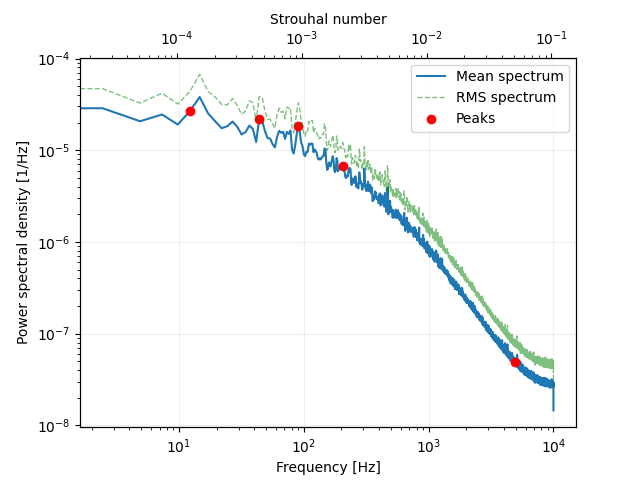

In [5]:
fig=plt.figure()
ax=fig.add_subplot(111)
plt.grid(alpha=.2)
p1,=ax.plot(f, meanSpectrum)
plt.xlabel("Frequency [Hz]");
plt.ylabel("Power spectral density [1/Hz]");
ax2=ax.twiny()
p2,=ax2.plot(Str, stdSpectrum,ls='--',lw=1,c='g',alpha=.5)
plt.xlabel("Strouhal number");

ax.set_xscale('log'); ax2.set_xscale('log')
ax.set_yscale('log'); ax2.set_yscale('log')

# Find peaks, and remove those that overlap too much
nn = np.where(meanSpectrum==np.nanmax(meanSpectrum))[0][0]
top_indices = np.argpartition(-meanSpectrum, nn)[:50]

bw = 10 # Hz
bw_frac = 0.2
def bracket_freq(fcent):
    fmin=np.round(fcent*(1-bw_frac)-bw,1)
    fmax=np.round(fcent*(1+bw_frac)+bw,1);
    if(fmin<0): fmin=0
    if(fmax>max(f)): fmax=max(f)
    return fmin, fmax


indices=[top_indices[0]]
for i in top_indices[1:]:
    fcent=f[i]
    fmin, fmax = bracket_freq(fcent)
    overlapping = np.any([ (f[j]>fmin) & (f[j]<fmax) for j in indices ])
    if not overlapping: indices.append(i)

indices.append(2000) # high freq peak

print("Identified %i peaks" % len(indices))
print(f[indices])

p3=ax.scatter(f[indices],meanSpectrum[indices],c='r',zorder=2);
plt.legend([p1,p2,p3],["Mean spectrum","RMS spectrum","Peaks"]);

In [6]:
# Create directory to save figures
output_dir=output_prefix+'_figures'
if not os.path.exists(output_dir): os.mkdir(output_dir)

# Save above
plt.savefig(output_dir+"/spatial_average_spectrum.pdf");

Generating figure: f = 0 - 24.6 Hz
	 created figure & saved
Generating figure: f = 25.2 - 62.7 Hz
	 created figure & saved
Generating figure: f = 62.3 - 118.4 Hz
	 created figure & saved
Generating figure: f = 156 - 259 Hz
	 created figure & saved
Generating figure: f = 0 - 10 Hz
	 created figure & saved
Generating figure: f = 3896.2 - 5869.4 Hz
	 created figure & saved


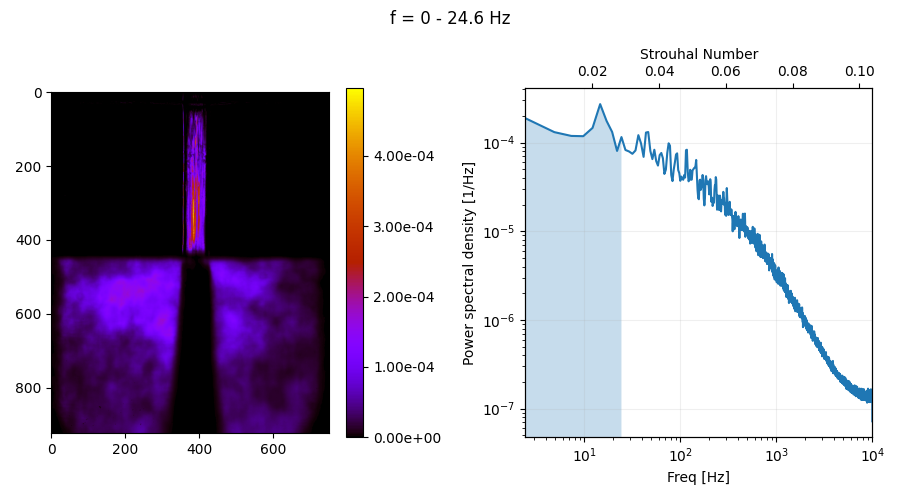

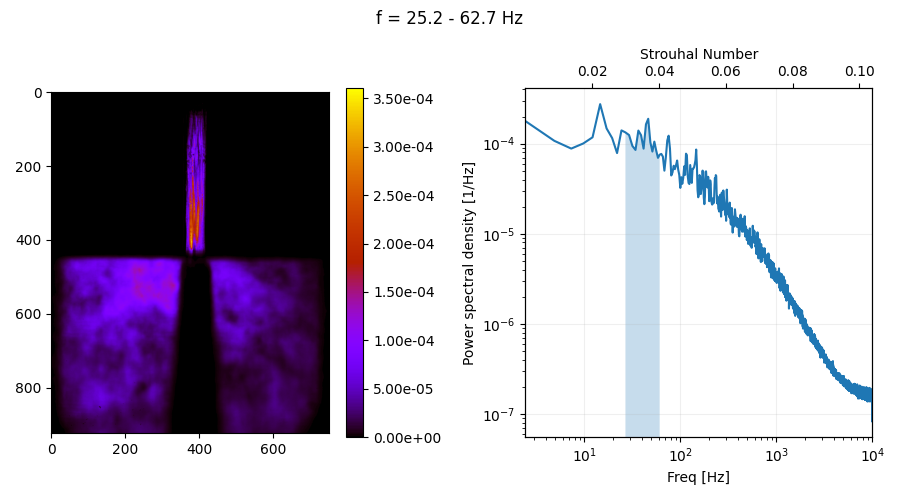

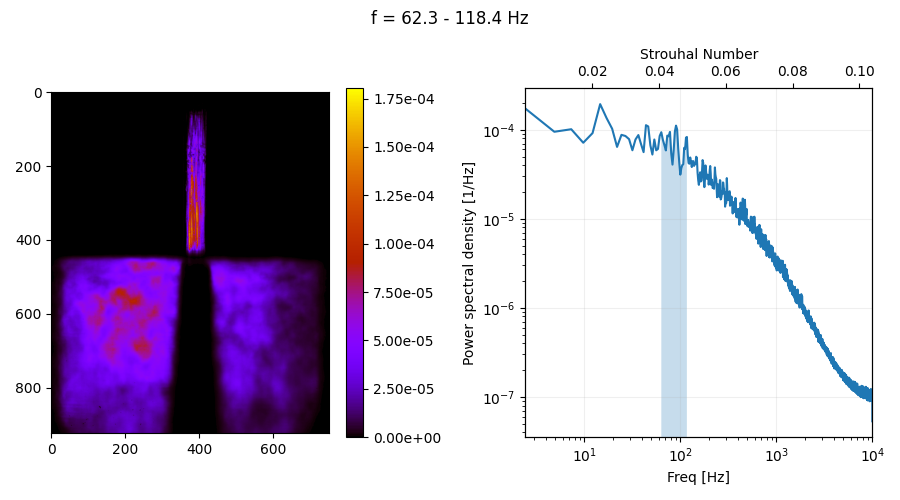

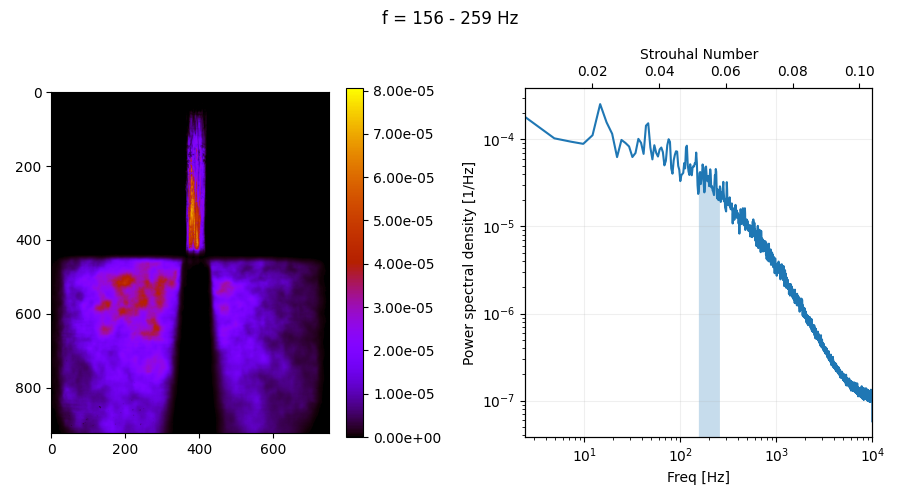

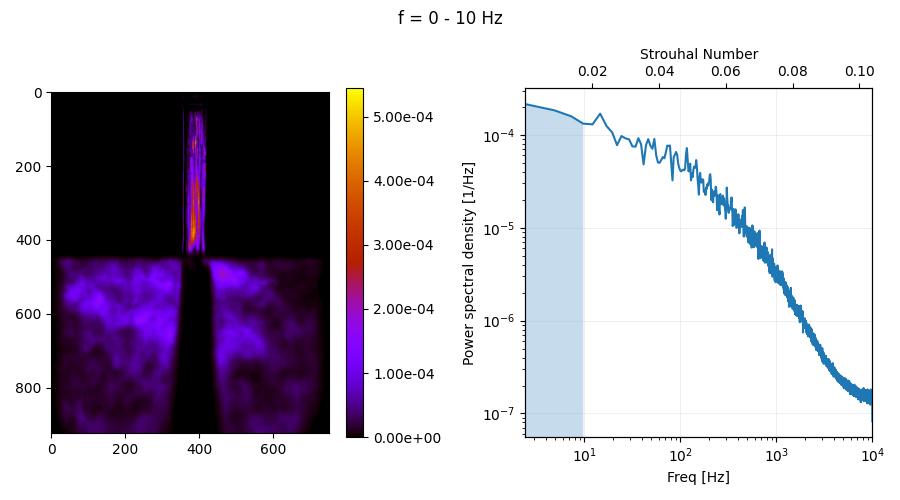

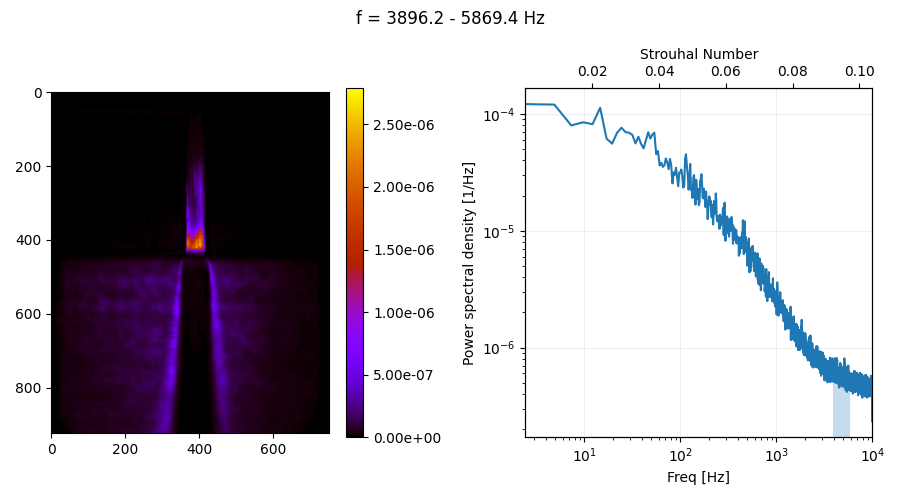

In [7]:
for fcent in f[indices]:
    fmin, fmax = bracket_freq(fcent)
    descr="f = %g - %g Hz" % (fmin,fmax)
    print("Generating figure: %s" % descr)
    
    # Integral of part of spectrum in frequency range
    fbin = np.where((f>=fmin) & (f<=fmax))[0]
    Pxx_bin = np.zeros((Pxx.shape[0],Pxx.shape[1]),dtype=np.float32)
    for i in range(Pxx.shape[0]): # integrate per-row assuming very large array
        for b in fbin:
            Pxx_bin[i,:] += Pxx[i,:,b]
        
    Pxx_bin /= float(len(fbin))

    # Spectrum of pixels where integral is above threshold
    thr = np.nanmean(Pxx_bin) + 2*np.nanstd(Pxx_bin)
    meanSpectrumConditional=np.nanmean(Pxx[Pxx_bin>thr,:],axis=0)

    fig=plt.figure(figsize=(9,5))
    ax=fig.add_subplot(121)
    h=ax.imshow(Pxx_bin,cmap='gnuplot')
    plt.colorbar(h, format='%.2e');
    
    ax=fig.add_subplot(122)
    plt.grid(alpha=.2)
    ax.loglog(f, meanSpectrumConditional)
    if len(fbin)<2: fbin = np.hstack(( fbin[0]-1, fbin, fbin[-1]+2 ))
    ax.fill_between(f[fbin],0*meanSpectrumConditional[fbin],meanSpectrumConditional[fbin],alpha=.25)
    plt.xlabel("Freq [Hz]")
    plt.ylabel("Power spectral density [1/Hz]");
    plt.xlim(f[1:].min(),f.max()) # skip f=0 in log
    ax2=ax.twiny()
    plt.xlim(Str[1:].min(), Str.max()) # skip Str=0 in log
    #ax2.loglog(Str,meanSpectrumConditional)
    plt.xlabel("Strouhal Number")    
    plt.suptitle(descr);
    plt.tight_layout();
    plt.savefig(output_dir+"/bracketing_f%fHz.pdf" % fcent);
    
    print('\t created figure & saved');
    #break
    
    #
    

---
## Stage 4. Analyse spectra and produce graphs
### Streamwise spectral waterfall plots

In [1]:
# reload modules if starting script here.
import numpy as np
import os, gc

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'

# Load data back
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_spectra.npz'
with np.load(npy_path) as file:
    f = file['f']
    Str = file['Str']
    Pxx = file['Pxx']

print("Read %s %s spectra array from %s" % (Pxx.shape, Pxx.dtype, os.path.basename(npy_path)))

gc.collect();

Read (924, 526, 4097) float32 spectra array from nz_0__5_3_co2_00_Re_1__5E4_K_1__12_spectra.npz


In [2]:
# tranverse spatially averaged spectra

# Calculate average in a loop to save memory
meanSpectrum = np.zeros((Pxx.shape[0],Pxx.shape[2]))
stdSpectrum = np.zeros((Pxx.shape[0],Pxx.shape[2]))
sumSpectrum = np.zeros((Pxx.shape[0],Pxx.shape[1]))
for i in range(Pxx.shape[0]):
    meanSpectrum[i,:] = np.nanmean(Pxx[i,:,:],axis=0)
    stdSpectrum[i,:] =  np.nanstd (Pxx[i,:,:],axis=0)
    sumSpectrum[i,:] += np.nansum(Pxx[i,:,:],axis=-1)
    if i%50==0: print(i)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900


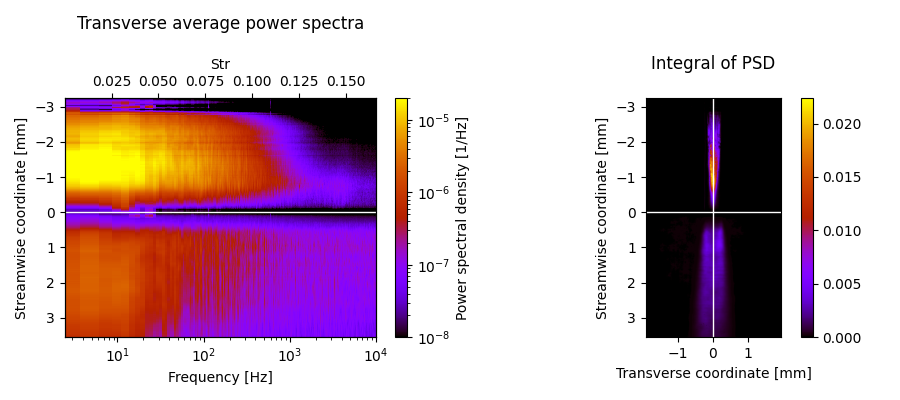

In [9]:
spatial_resolution=7.35 #um/px
x0=440 # px exit plane
y0=260 # px centerline

Pmin=1e-8 #meanSpectrum.min()
Pmax=2e-5 #meanSpectrum.max()

x_coords =  (np.arange(0,Pxx.shape[0])-x0)*spatial_resolution*1e-3
y_coords =  (np.arange(0,Pxx.shape[1])-y0)*spatial_resolution*1e-3

fig=plt.figure(figsize=(9,4))

ax=fig.add_subplot(121)

ph=ax.pcolormesh(f,x_coords,meanSpectrum,cmap='gnuplot',\
                 norm=mpl.colors.LogNorm(vmin=Pmin, vmax=Pmax));
plt.gca().set_xscale('log')
plt.xlim(f[1],f.max())
ax.invert_yaxis()
ax.set_aspect('auto')

plt.axhline(0,c='w',lw=1) # debug-check axes alignment

cb=plt.colorbar(ph)
cb.set_label("Power spectral density [1/Hz]")
plt.xlabel("Frequency [Hz]");
plt.ylabel("Streamwise coordinate [mm]");
plt.title("Transverse average power spectra\n");

ax2=ax.twiny()
plt.xlim(Str[1],Str.max())
plt.xlabel("Str");

ax=fig.add_subplot(122)
ph=ax.imshow(sumSpectrum,cmap='gnuplot',extent=[y_coords.min(), y_coords.max(), x_coords.max(), x_coords.min()])
cb=plt.colorbar(ph)
plt.xlabel("Transverse coordinate [mm]")
plt.ylabel("Streamwise coordinate [mm]");
plt.title("Integral of PSD\n");
plt.axhline(0,c='w',lw=1); plt.axvline(0,c='w',lw=1) # debug-check axes alignment

plt.tight_layout();

In [10]:
# Create directory to save figures
output_dir=output_prefix+'_figures'
if not os.path.exists(output_dir): os.mkdir(output_dir)

# Save above
plt.savefig(output_dir+"/traverse_average_spectra.png", dpi=300);